# Import and Load Data

In [26]:
import numpy as np
import pandas as pd
from scipy.optimize import least_squares, minimize_scalar
import matplotlib.pyplot as plt

df = pd.read_csv("/content/xy_data.csv")
x = df['x'].values
y = df['y'].values
n = len(x)

print(f"Loaded {n} points")
print(df.describe())

Loaded 1500 points
                 x            y
count  1500.000000  1500.000000
mean     83.713931    58.263519
std      13.697157     7.696524
min      59.657204    46.032295
25%      72.282910    51.124211
50%      84.710995    57.681288
75%      93.368257    66.138374
max     109.231520    69.685510


# Curve Model

In [27]:
def curve_point(t, theta, M, X):
    osc = np.exp(M * np.abs(t)) * np.sin(0.3 * t)
    cx = t * np.cos(theta) - osc * np.sin(theta) + X
    cy = 42 + t * np.sin(theta) + osc * np.cos(theta)
    return cx, cy

# t-Fit

In [29]:
T_MIN, T_MAX = 6.0, 60.0
T_GRID = np.linspace(T_MIN, T_MAX, 500)

def best_t_for_point(px, py, theta, M, X):
    def sq_dist(t):
        cx, cy = curve_point(t, theta, M, X)
        return (cx - px)**2 + (cy - py)**2

    grid_dists = sq_dist(T_GRID)
    t0 = T_GRID[np.argmin(grid_dists)]

    lo, hi = max(T_MIN, t0 - 1.0), min(T_MAX, t0 + 1.0)
    res = minimize_scalar(sq_dist, bounds=(lo, hi), method='bounded')
    return res.x

In [21]:
def residuals(params, t_values):
    theta, M, X = params
    cx, cy = curve_point(t_values, theta, M, X)
    return np.concatenate([cx - x, cy - y])

theta_guess, M_guess, X_guess = np.radians(25), 0.0, 50.0
params = np.array([theta_guess, M_guess, X_guess])
t_values = np.linspace(T_MIN, T_MAX, n)
BOUNDS = ([0.0, -0.05, 0.0], [np.radians(50), 0.05, 100.0])

for iteration in range(30):
    res = least_squares(residuals, params, args=(t_values,), bounds=BOUNDS)
    params = res.x
    theta, M, X = params

    new_t_values = np.array([best_t_for_point(x[i], y[i], theta, M, X) for i in range(n)])
    change = np.abs(new_t_values - t_values).max()
    t_values = new_t_values

    print(f"iter {iteration:2d}: theta={np.degrees(theta):7.4f} deg  M={M:8.5f}  X={X:7.4f}  max_t_change={change:.6f}")
    if change < 1e-6:
        print("Converged.")
        break

print("\nFinal fitted parameters:")
print(f"theta = {np.degrees(theta):.6f} deg  ({theta:.6f} rad)")
print(f"M     = {M:.6f}")
print(f"X     = {X:.6f}")

iter  0: theta=29.5823 deg  M=-0.05000  X=55.0135  max_t_change=52.103975
iter  1: theta=30.0032 deg  M= 0.02985  X=55.0224  max_t_change=0.101836
iter  2: theta=30.0071 deg  M= 0.02997  X=55.0163  max_t_change=0.017176
iter  3: theta=30.0066 deg  M= 0.03000  X=55.0121  max_t_change=0.005611
iter  4: theta=30.0053 deg  M= 0.03000  X=55.0089  max_t_change=0.002980
iter  5: theta=30.0041 deg  M= 0.03000  X=55.0066  max_t_change=0.002130
iter  6: theta=30.0030 deg  M= 0.03000  X=55.0049  max_t_change=0.001583
iter  7: theta=30.0023 deg  M= 0.03000  X=55.0037  max_t_change=0.001177
iter  8: theta=30.0017 deg  M= 0.03000  X=55.0027  max_t_change=0.000874
iter  9: theta=30.0012 deg  M= 0.03000  X=55.0020  max_t_change=0.000651
iter 10: theta=30.0009 deg  M= 0.03000  X=55.0015  max_t_change=0.000481
iter 11: theta=30.0007 deg  M= 0.03000  X=55.0011  max_t_change=0.000360
iter 12: theta=30.0005 deg  M= 0.03000  X=55.0008  max_t_change=0.000265
iter 13: theta=30.0004 deg  M= 0.03000  X=55.0006 

# L1 Residual

In [22]:
cx_fit, cy_fit = curve_point(t_values, theta, M, X)
abs_err = np.abs(cx_fit - x) + np.abs(cy_fit - y)

print(f"Mean L1 residual per point : {abs_err.mean():.8f}")
print(f"Max  L1 residual           : {abs_err.max():.8f}")
print(f"Total L1 residual (sum)    : {abs_err.sum():.8f}")

Mean L1 residual per point : 0.00000374
Max  L1 residual           : 0.00001684
Total L1 residual (sum)    : 0.00561114


# Plots

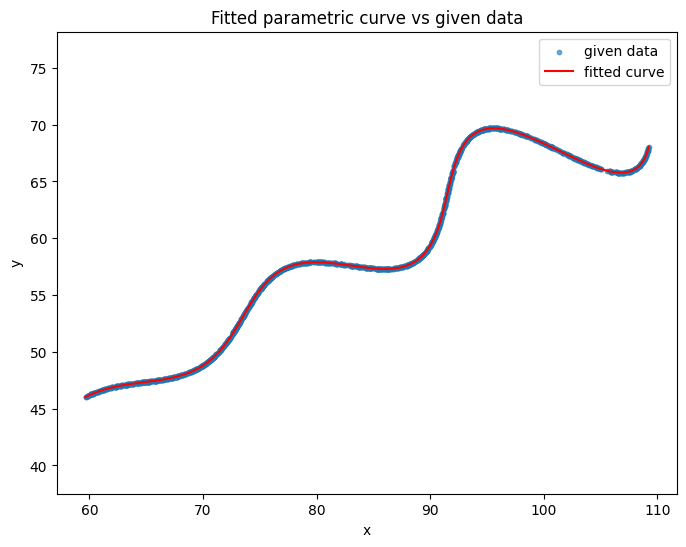

In [24]:
t_dense = np.linspace(T_MIN, T_MAX, 1000)
cx_dense, cy_dense = curve_point(t_dense, theta, M, X)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.6, label='given data')
plt.plot(cx_dense, cy_dense, 'r-', linewidth=1.5, label='fitted curve')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Fitted parametric curve vs given data')
plt.legend(); plt.axis('equal')
plt.savefig('fit_check.png', dpi=150)
plt.show()

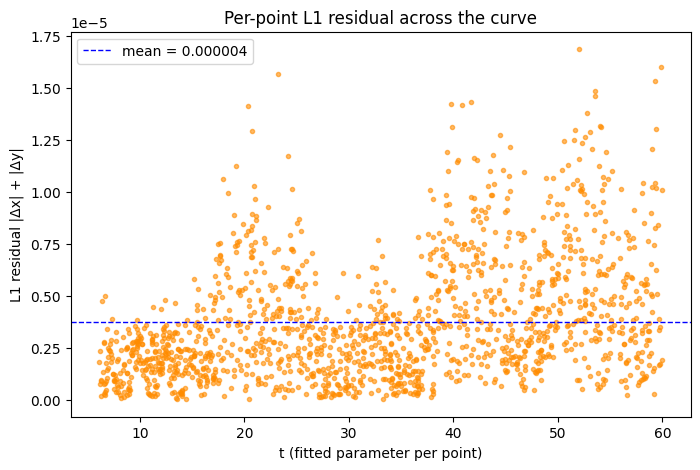

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(t_values, abs_err, 'o', markersize=3, alpha=0.6, color='darkorange')
plt.axhline(abs_err.mean(), color='blue', linestyle='--', linewidth=1,
            label=f'mean = {abs_err.mean():.6f}')
plt.xlabel('t (fitted parameter per point)')
plt.ylabel('L1 residual |Δx| + |Δy|')
plt.title('Per-point L1 residual across the curve')
plt.legend()
plt.savefig('l1_error.png', dpi=150)
plt.show()